# Home Credit Default Risk: complete project
Data prep -> EDA -> bureau features -> IV -> modelling -> evaluation -> saved artifacts.

Requirements: pip install -U pandas numpy matplotlib seaborn scikit-learn lightgbm joblib kagglehub
Works as a plain script (python home_credit_risk_complete.py) or cell-by-cell
in VS Code / Jupyter (the "# %%" markers are cell separators).

## Imports and configuration

In [2]:
%pip install -U lightgbm scikit-learn joblib kagglehub seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import zipfile
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, QuantileTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix,
                             ConfusionMatrixDisplay)

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
COMPETITION = "home-credit-default-risk"
SHOW_EDA = True            # set False to skip the EDA plots
COST_FN, COST_FP = 5, 1    # business cost of a missed defaulter vs a rejected good customer

# Use your own helpers if src/utils.py exists, otherwise fall back to these.
try:
    from src.utils import unzip_file, minimize_memory_usage
except ImportError:
    def unzip_file(zip_path, dest):
        os.makedirs(dest, exist_ok=True)
        with zipfile.ZipFile(zip_path) as z:
            z.extractall(dest)

    def minimize_memory_usage(df, name=""):
        before = df.memory_usage(deep=True).sum() / 1024 ** 2
        for c in df.columns:
            s = df[c]
            if pd.api.types.is_integer_dtype(s):
                df[c] = pd.to_numeric(s, downcast="integer")
            elif pd.api.types.is_float_dtype(s):
                df[c] = pd.to_numeric(s, downcast="float")
        after = df.memory_usage(deep=True).sum() / 1024 ** 2
        print(f"Memory usage of {name} before optimization: {before:.2f} MB")
        print(f"Memory usage of {name} after optimization: {after:.2f} MB")
        return df


def show():
    if SHOW_EDA:
        plt.show()
    else:
        plt.close("all")

## 1. Load data

In [4]:
import kagglehub
kagglehub.login()

In [5]:
# Requires: pip install -U kagglehub, a Kaggle login (kagglehub.login() or
# ~/.kaggle/kaggle.json) and having clicked "Join Competition" once on Kaggle.
import kagglehub

DATA_DIR = kagglehub.competition_download(COMPETITION)


def find_data_dir(root, target="application_train.csv"):
    """Locate the folder holding the CSVs (handles subfolders / an unextracted zip)."""
    for folder, _, files in os.walk(root):
        if target in files:
            return folder
    for folder, _, files in os.walk(root):          # zip left unextracted
        for f in files:
            if f.endswith(".zip"):
                with zipfile.ZipFile(os.path.join(folder, f)) as z:
                    z.extractall(os.path.join(root, "extracted"))
                return find_data_dir(os.path.join(root, "extracted"), target)
    raise FileNotFoundError(f"{target} not found under {root}")


DATA_DIR = find_data_dir(DATA_DIR)
print("Data folder:", DATA_DIR, "->", sorted(os.listdir(DATA_DIR)))

main = pd.read_csv(os.path.join(DATA_DIR, "application_train.csv"))
main = minimize_memory_usage(main, "application_train.csv")

description = pd.read_csv(os.path.join(DATA_DIR, "HomeCredit_columns_description.csv"),
                          encoding="ISO-8859-1")
bureau = pd.read_csv(os.path.join(DATA_DIR, "bureau.csv"))
bureau = minimize_memory_usage(bureau, "bureau.csv")

print("Shape:", main.shape)
print("Duplicate rows:", main.duplicated().sum())

# Column descriptions (lookup only, not used by the model)
column_description = {}
for col in main.columns:
    match = description[description["Row"] == col]["Description"].values
    column_description[col] = match[0] if len(match) else "n/a"

100%|██████████| 688M/688M [02:54<00:00, 4.13MB/s] 

Extracting files...


Data folder: C:\Users\krati\.cache\kagglehub\competitions\home-credit-default-risk -> ['HomeCredit_columns_description.csv', 'POS_CASH_balance.csv', 'application_test.csv', 'application_train.csv', 'bureau.csv', 'bureau_balance.csv', 'credit_card_balance.csv', 'installments_payments.csv', 'previous_application.csv', 'sample_submission.csv']
Memory usage of application_train.csv before optimization: 504.99 MB
Memory usage of application_train.csv after optimization: 348.09 MB
Memory usage of bureau.csv before optimization: 472.82 MB
Memory usage of bureau.csv after optimization: 408.99 MB
Shape: (307511, 122)
Duplicate rows: 0


## 2. Missing values

In [6]:
miss_pct = main.isnull().mean() * 100
cols_over_50 = miss_pct[miss_pct > 50].index.tolist()
print("Columns with >50% missing:", len(cols_over_50))
main = main.drop(columns=cols_over_50)

miss_pct = main.isnull().mean() * 100
cols_over_10 = miss_pct[miss_pct > 10].index.tolist()
print("Columns with >10% missing:", len(cols_over_10))

# NaN flags for columns with substantial missingness
for col in cols_over_10:
    main[f"{col}_NAN_FLAG"] = main[col].isnull().astype(int)

# Median for numeric, mode for categorical.
# NOTE: is_numeric_dtype is used because after memory minimisation the dtypes are
# float16/float32/int8..., so a check against ['float64','int64'] misses them.
for col in main.columns:
    if main[col].isnull().any():
        if pd.api.types.is_numeric_dtype(main[col]):
            main[col] = main[col].fillna(main[col].median())
        else:
            main[col] = main[col].fillna(main[col].mode()[0])

print("Columns still containing nulls:", main.isnull().any().sum())

Columns with >50% missing: 41
Columns with >10% missing: 16
Columns still containing nulls: 0


## 3. Fix data types and invalid values

In [7]:
main["AGE_YEARS"] = (-main["DAYS_BIRTH"]) // 365

# 365243 is a placeholder for "not employed / pensioner", not a real value
main["DAYS_EMPLOYED_ANOM"] = (main["DAYS_EMPLOYED"] == 365243).astype(int)
main["DAYS_EMPLOYED"] = main["DAYS_EMPLOYED"].replace(365243, np.nan)
main["YEARS_EMPLOYED"] = (-main["DAYS_EMPLOYED"]) // 365
main["YEARS_EMPLOYED"] = main["YEARS_EMPLOYED"].fillna(main["YEARS_EMPLOYED"].median())

main["YEARS_REGISTRATION"] = (-main["DAYS_REGISTRATION"]) // 365
main["YEARS_ID_PUBLISH"] = (-main["DAYS_ID_PUBLISH"]) // 365
main = main.drop(columns=["DAYS_BIRTH", "DAYS_EMPLOYED", "DAYS_REGISTRATION", "DAYS_ID_PUBLISH"])

main = main[main["CODE_GENDER"] != "XNA"].reset_index(drop=True)

## 4. Feature engineering

In [8]:
# Share of defaulters in the applicant's social circle
main["DEF_30_RATIO"] = (main["DEF_30_CNT_SOCIAL_CIRCLE"]
                        / main["OBS_30_CNT_SOCIAL_CIRCLE"].replace(0, np.nan) * 100).fillna(0)
main["DEF_60_RATIO"] = (main["DEF_60_CNT_SOCIAL_CIRCLE"]
                        / main["OBS_60_CNT_SOCIAL_CIRCLE"].replace(0, np.nan) * 100).fillna(0)

main["INCOME_BY_CREDIT"] = main["AMT_INCOME_TOTAL"] / main["AMT_CREDIT"]
main["GOODS_AMT_BY_CREDIT"] = main["AMT_GOODS_PRICE"] / main["AMT_CREDIT"]
main["ANNUITY_BY_INCOME"] = main["AMT_ANNUITY"] / main["AMT_INCOME_TOTAL"]

bins = [0, 14, 25, 59, int(main["AGE_YEARS"].max())]
labels = ["1-14", "15-25", "26-59", "60+"]
main["AGE_BIN"] = pd.cut(main["AGE_YEARS"], bins=bins, labels=labels, right=True)

## 5. Drop redundant columns

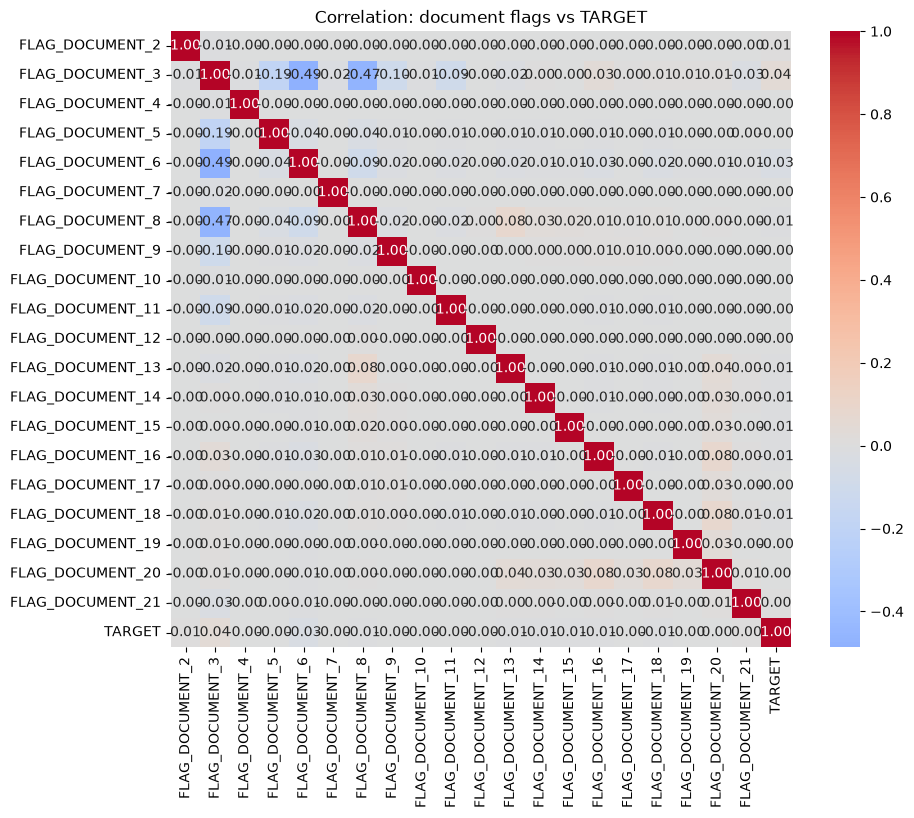

Columns left: 43


In [9]:
doc_cols = [f"FLAG_DOCUMENT_{i}" for i in range(2, 22)]
doc_cols = [c for c in doc_cols if c in main.columns]

if SHOW_EDA:
    plt.figure(figsize=(10, 8))
    sns.heatmap(main[doc_cols + ["TARGET"]].corr(numeric_only=True),
                annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Correlation: document flags vs TARGET")
    show()

main = main.drop(columns=doc_cols)

redundant_features = [
    "AMT_REQ_CREDIT_BUREAU_HOUR", "AMT_REQ_CREDIT_BUREAU_QRT", "AMT_REQ_CREDIT_BUREAU_MON",
    "AMT_REQ_CREDIT_BUREAU_WEEK", "AMT_REQ_CREDIT_BUREAU_DAY", "CNT_CHILDREN",
    "YEARS_BEGINEXPLUATATION_MODE", "FLOORSMAX_MODE", "YEARS_BEGINEXPLUATATION_MEDI",
    "FLOORSMAX_MEDI", "EMERGENCYSTATE_MODE", "TOTALAREA_MODE",
    "OBS_60_CNT_SOCIAL_CIRCLE", "DEF_60_CNT_SOCIAL_CIRCLE",
    "OBS_30_CNT_SOCIAL_CIRCLE", "DEF_30_CNT_SOCIAL_CIRCLE",
    "LIVE_CITY_NOT_WORK_CITY", "REGION_RATING_CLIENT", "REG_CITY_NOT_WORK_CITY",
    "REG_CITY_NOT_LIVE_CITY", "HOUR_APPR_PROCESS_START", "WEEKDAY_APPR_PROCESS_START",
    "REGION_RATING_CLIENT_W_CITY", "FLAG_EMAIL", "FLAG_PHONE", "FLAG_WORK_PHONE",
    "FLAG_EMP_PHONE", "FLAG_MOBIL", "REGION_POPULATION_RELATIVE", "NAME_TYPE_SUITE",
    "YEARS_BEGINEXPLUATATION_MODE_NAN_FLAG", "YEARS_BEGINEXPLUATATION_MEDI_NAN_FLAG",
    "TOTALAREA_MODE_NAN_FLAG", "FLOORSMAX_MODE_NAN_FLAG", "FLOORSMAX_MEDI_NAN_FLAG",
    "EMERGENCYSTATE_MODE_NAN_FLAG", "AMT_REQ_CREDIT_BUREAU_HOUR_NAN_FLAG",
    "AMT_REQ_CREDIT_BUREAU_DAY_NAN_FLAG", "AMT_REQ_CREDIT_BUREAU_WEEK_NAN_FLAG",
    "AMT_REQ_CREDIT_BUREAU_MON_NAN_FLAG", "AMT_REQ_CREDIT_BUREAU_QRT_NAN_FLAG",
]
main = main.drop(columns=redundant_features, errors="ignore")
print("Columns left:", main.shape[1])

# Ratio features can contain inf (division by zero)
main = main.replace([np.inf, -np.inf], np.nan)
for c in ["INCOME_BY_CREDIT", "GOODS_AMT_BY_CREDIT", "ANNUITY_BY_INCOME"]:
    main[c] = main[c].fillna(main[c].median())

## 6. Outlier report (IQR method; informational, tree models are robust to outliers)

In [10]:
print("\nPERCENTAGE OF OUTLIERS IN EACH NUMERIC COLUMN\n")
for col in main.select_dtypes(include="number").columns:
    q1, q3 = main[col].quantile(0.25), main[col].quantile(0.75)
    iqr = q3 - q1
    n_out = ((main[col] < q1 - 1.5 * iqr) | (main[col] > q3 + 1.5 * iqr)).sum()
    print(f"{col}: {n_out / len(main) * 100:.2f}%")


PERCENTAGE OF OUTLIERS IN EACH NUMERIC COLUMN

SK_ID_CURR: 0.00%
TARGET: 8.07%
AMT_INCOME_TOTAL: 4.56%
AMT_CREDIT: 2.13%
AMT_ANNUITY: 2.44%
AMT_GOODS_PRICE: 4.79%
FLAG_CONT_MOBILE: 0.19%
CNT_FAM_MEMBERS: 1.30%
REG_REGION_NOT_LIVE_REGION: 1.51%
REG_REGION_NOT_WORK_REGION: 5.08%
LIVE_REGION_NOT_WORK_REGION: 4.07%
EXT_SOURCE_2: 0.00%
EXT_SOURCE_3: 1.40%
YEARS_BEGINEXPLUATATION_AVG: 46.18%
FLOORSMAX_AVG: 30.12%
DAYS_LAST_PHONE_CHANGE: 0.14%
AMT_REQ_CREDIT_BUREAU_YEAR: 2.35%
OCCUPATION_TYPE_NAN_FLAG: 0.00%
EXT_SOURCE_3_NAN_FLAG: 19.83%
YEARS_BEGINEXPLUATATION_AVG_NAN_FLAG: 0.00%
FLOORSMAX_AVG_NAN_FLAG: 0.00%
AMT_REQ_CREDIT_BUREAU_YEAR_NAN_FLAG: 13.50%
AGE_YEARS: 0.00%
DAYS_EMPLOYED_ANOM: 18.01%
YEARS_EMPLOYED: 7.61%
YEARS_REGISTRATION: 0.21%
YEARS_ID_PUBLISH: 0.00%
DEF_30_RATIO: 11.44%
DEF_60_RATIO: 8.38%
INCOME_BY_CREDIT: 5.71%
GOODS_AMT_BY_CREDIT: 0.16%
ANNUITY_BY_INCOME: 2.56%


## 7. EDA


Default rate: 8.07%  (imbalanced dataset)


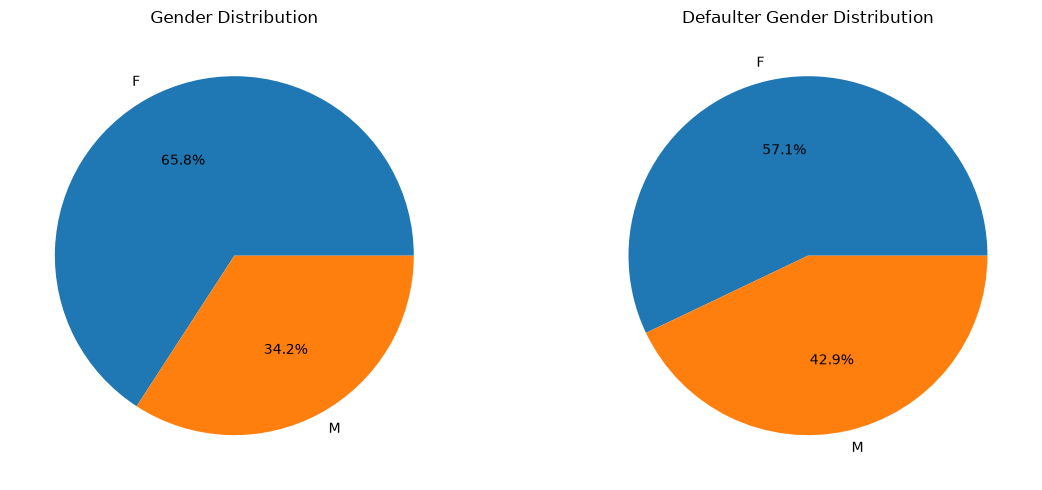

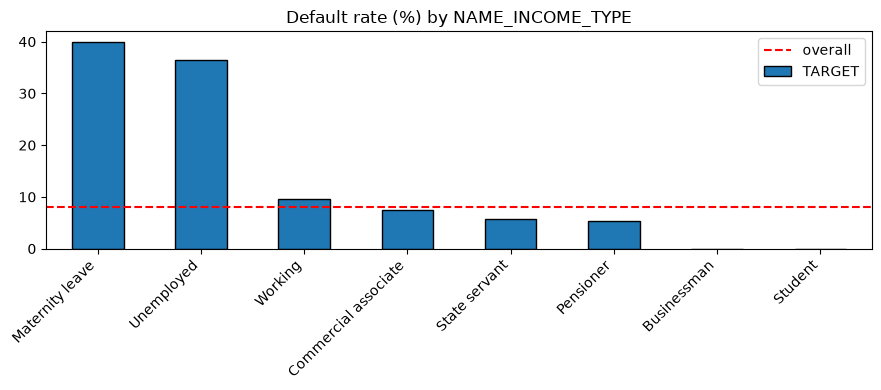

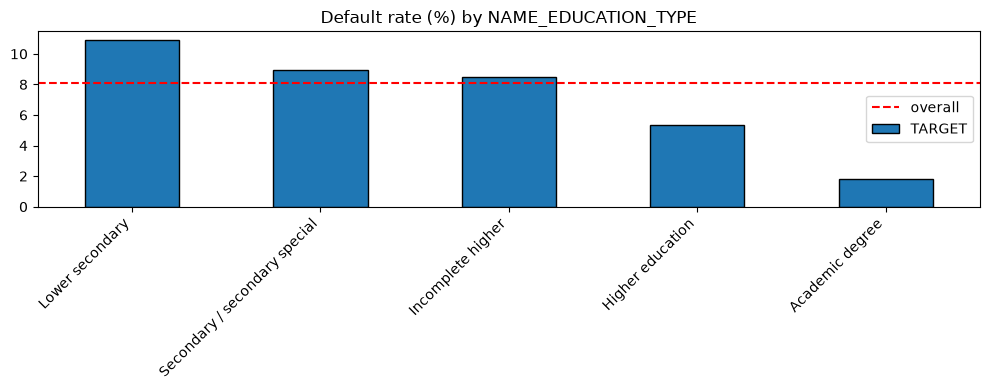

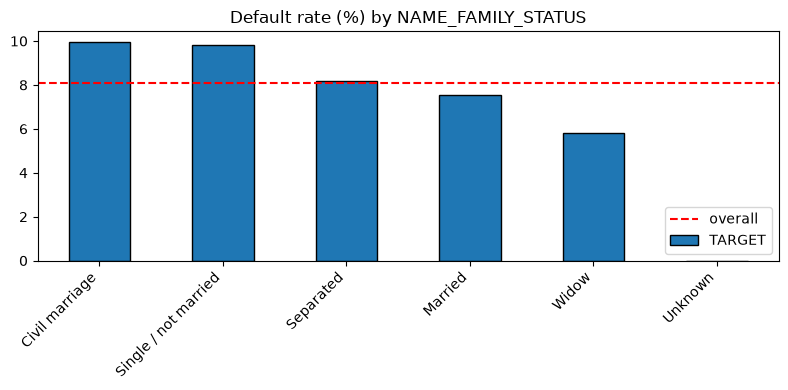

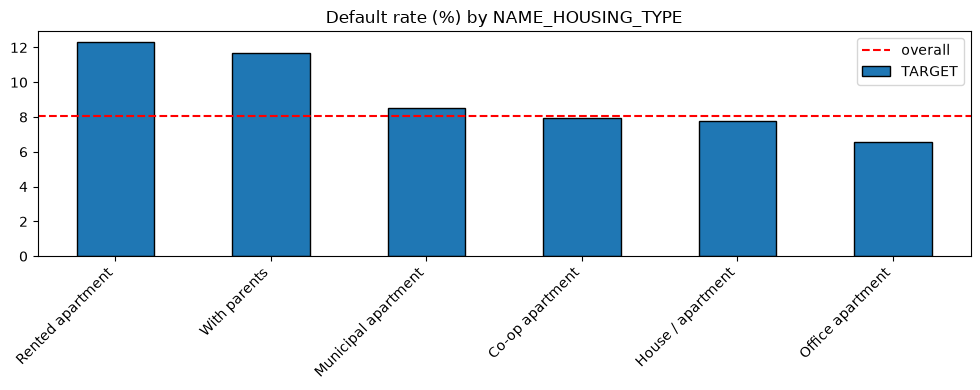

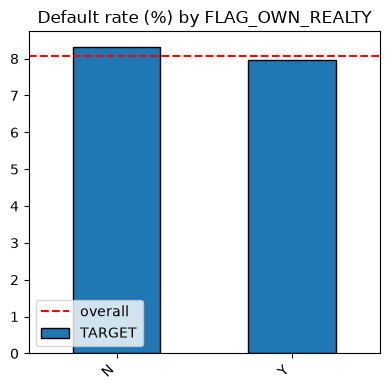

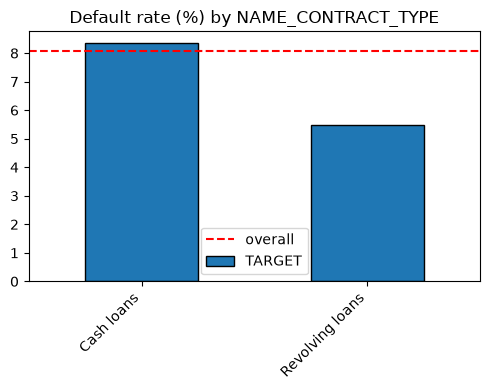

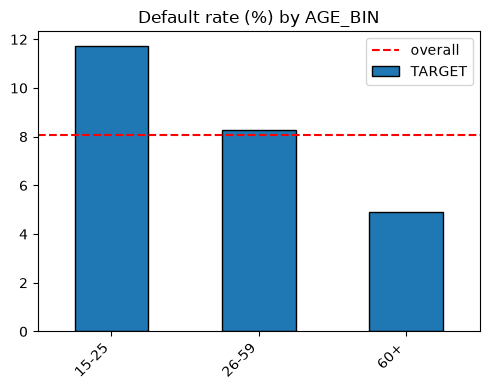

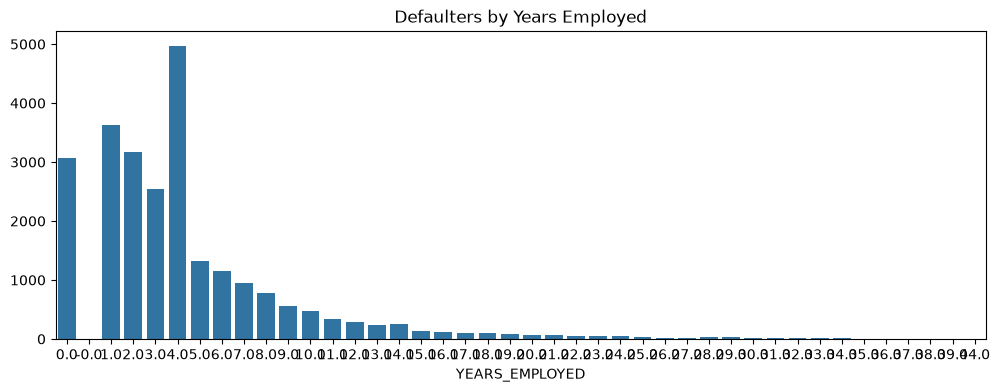

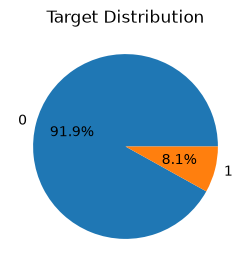

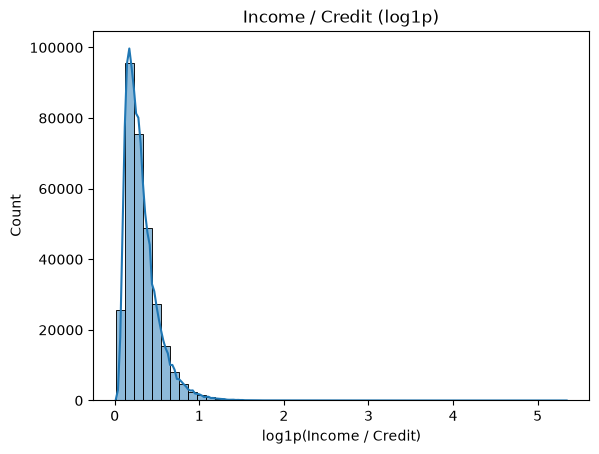

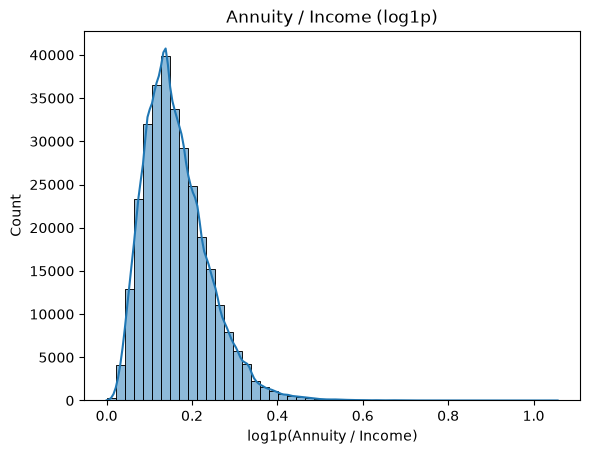

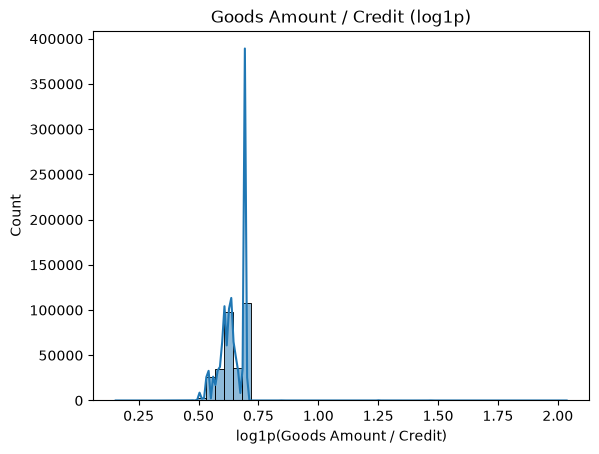

In [11]:
print(f"\nDefault rate: {main['TARGET'].mean():.2%}  (imbalanced dataset)")

if SHOW_EDA:
    # Gender: overall vs defaulters
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    main["CODE_GENDER"].value_counts().plot.pie(autopct="%1.1f%%", title="Gender Distribution")
    plt.ylabel("")
    plt.subplot(1, 2, 2)
    main[main["TARGET"] == 1]["CODE_GENDER"].value_counts().plot.pie(
        autopct="%1.1f%%", title="Defaulter Gender Distribution")
    plt.ylabel("")
    plt.tight_layout()
    show()

    # Default RATE by category (more informative than raw defaulter counts,
    # since big groups always have more defaulters)
    for col, w in [("NAME_INCOME_TYPE", 9), ("NAME_EDUCATION_TYPE", 10),
                   ("NAME_FAMILY_STATUS", 8), ("NAME_HOUSING_TYPE", 10),
                   ("FLAG_OWN_REALTY", 4), ("NAME_CONTRACT_TYPE", 5), ("AGE_BIN", 5)]:
        rate = main.groupby(col, observed=True)["TARGET"].mean().sort_values(ascending=False) * 100
        plt.figure(figsize=(w, 4))
        rate.plot(kind="bar", edgecolor="black")
        plt.axhline(main["TARGET"].mean() * 100, color="red", ls="--", label="overall")
        plt.title(f"Default rate (%) by {col}")
        plt.xlabel("")
        plt.xticks(rotation=45, ha="right")
        plt.legend()
        plt.tight_layout()
        show()

    # Years employed
    plt.figure(figsize=(12, 4))
    sns.countplot(data=main[main["TARGET"] == 1], x="YEARS_EMPLOYED")
    plt.title("Defaulters by Years Employed")
    plt.ylabel("")
    show()

    # Target distribution
    main["TARGET"].value_counts().plot.pie(autopct="%1.1f%%", figsize=(3, 3),
                                           title="Target Distribution")
    plt.ylabel("")
    show()

    # Ratio distributions (log1p view because of heavy right skew)
    for c, t in [("INCOME_BY_CREDIT", "Income / Credit"),
                 ("ANNUITY_BY_INCOME", "Annuity / Income"),
                 ("GOODS_AMT_BY_CREDIT", "Goods Amount / Credit")]:
        sns.histplot(np.log1p(main[c].clip(lower=0)), bins=50, kde=True)
        plt.title(f"{t} (log1p)")
        plt.xlabel(f"log1p({t})")
        show()

## 8. Bureau features and merge

In [12]:
bureau["DEBT_CREDIT_RATIO"] = (bureau["AMT_CREDIT_SUM_DEBT"]
                               / bureau["AMT_CREDIT_SUM"].replace(0, np.nan))
bureau["HAS_OVERDUE"] = (bureau["AMT_CREDIT_SUM_OVERDUE"] > 0).astype(int)
bureau["IS_ACTIVE"] = (bureau["CREDIT_ACTIVE"] == "Active").astype(int)

bureau_agg = bureau.groupby("SK_ID_CURR").agg({
    "AMT_CREDIT_SUM": ["sum", "mean"],
    "AMT_CREDIT_SUM_DEBT": ["sum", "mean"],
    "DEBT_CREDIT_RATIO": "mean",
    "HAS_OVERDUE": "sum",
    "IS_ACTIVE": "sum",
    "DAYS_CREDIT": ["mean", "min"],
})
bureau_agg.columns = ["BUREAU_" + "_".join(c).upper() for c in bureau_agg.columns]
bureau_agg = bureau_agg.reset_index()
bureau_agg["HAS_BUREAU_RECORD"] = 1

main = main.merge(bureau_agg, on="SK_ID_CURR", how="left")

# Applicants with no bureau history: flag them, then median-impute the aggregates
main["HAS_BUREAU_RECORD"] = main["HAS_BUREAU_RECORD"].fillna(0).astype(int)
bureau_features = [c for c in main.columns if c.startswith("BUREAU_")]
main[bureau_features] = main[bureau_features].replace([np.inf, -np.inf], np.nan)
for col in bureau_features:
    main[col] = main[col].fillna(main[col].median())

print("Final shape:", main.shape)
print("Nulls remaining:", int(main.isnull().sum().sum()))

Final shape: (307507, 53)
Nulls remaining: 0


## 9. Weight of Evidence / Information Value

                                 Feature        IV
0                           EXT_SOURCE_3  0.313851
1                           EXT_SOURCE_2  0.306276
2          BUREAU_DEBT_CREDIT_RATIO_MEAN  0.135602
3                BUREAU_DAYS_CREDIT_MEAN  0.117921
4                         YEARS_EMPLOYED  0.095178
5                        AMT_GOODS_PRICE  0.091555
6                              AGE_YEARS  0.083584
7                      ORGANIZATION_TYPE  0.073368
8                 BUREAU_DAYS_CREDIT_MIN  0.072423
9                    GOODS_AMT_BY_CREDIT  0.071935
10                      NAME_INCOME_TYPE  0.058709
11       BUREAU_AMT_CREDIT_SUM_DEBT_MEAN  0.052822
12                   NAME_EDUCATION_TYPE  0.050835
13                       OCCUPATION_TYPE  0.049617
14                DAYS_LAST_PHONE_CHANGE  0.046691
15        BUREAU_AMT_CREDIT_SUM_DEBT_SUM  0.045384
16                            AMT_CREDIT  0.045079
17                  BUREAU_IS_ACTIVE_SUM  0.040718
18                           CO

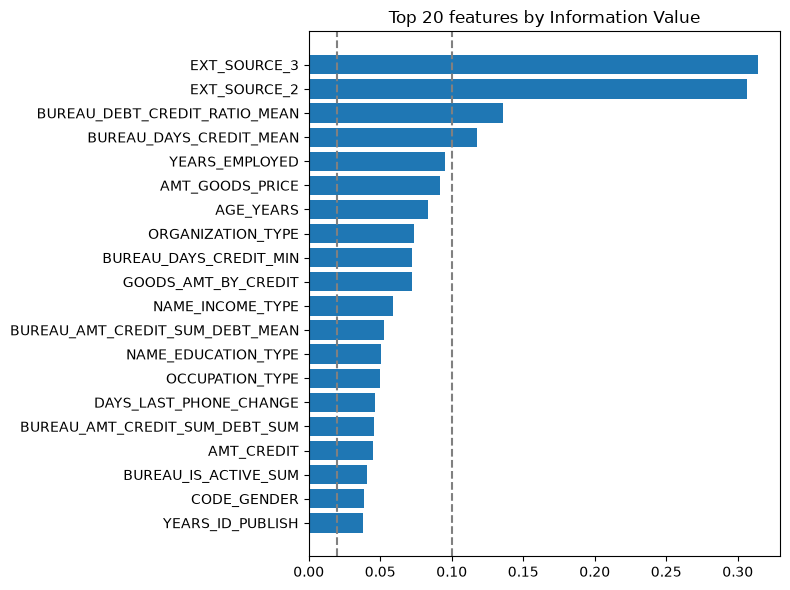

In [13]:
def calculate_woe_iv(df, feature, target, bins=10, eps=1e-6):
    """Return (WoE table, IV) for one feature.
    Casts to float64 (float16 breaks qcut), handles inf and categoricals."""
    s = df[feature]
    if isinstance(s.dtype, pd.CategoricalDtype) or not pd.api.types.is_numeric_dtype(s):
        binned = s.astype(str)
    else:
        s = s.astype("float64").replace([np.inf, -np.inf], np.nan)
        binned = s if s.nunique() <= bins else pd.qcut(s, q=bins, duplicates="drop")
    t = pd.DataFrame({"bin": binned, "y": df[target]}).dropna(subset=["bin"])
    g = t.groupby("bin", observed=True)["y"].agg(total="count", bads="sum")
    g["goods"] = g["total"] - g["bads"]
    g["dist_good"] = (g["goods"] / g["goods"].sum()).clip(lower=eps)
    g["dist_bad"] = (g["bads"] / g["bads"].sum()).clip(lower=eps)
    g["woe"] = np.log(g["dist_good"] / g["dist_bad"])
    g["iv"] = (g["dist_good"] - g["dist_bad"]) * g["woe"]
    return g[["total", "bads", "woe", "iv"]], g["iv"].sum()


def iv_summary(df, target, bins=10):
    rows = []
    for col in df.columns.drop(target):
        try:
            _, iv = calculate_woe_iv(df, col, target, bins)
        except Exception as e:
            print(f"IV failed for {col}: {e}")
            iv = np.nan
        rows.append((col, iv))
    return (pd.DataFrame(rows, columns=["Feature", "IV"])
            .sort_values("IV", ascending=False).reset_index(drop=True))


# IV < 0.02 useless | 0.02-0.1 weak | 0.1-0.3 medium | 0.3-0.5 strong | >0.5 check leakage
iv_result = iv_summary(main.drop(columns=["SK_ID_CURR"]), "TARGET")
print(iv_result.to_string())
print("\nFeatures with IV > 0.02:")
print(iv_result[iv_result["IV"] > 0.02].to_string())

if SHOW_EDA:
    top = iv_result.dropna().head(20).iloc[::-1]
    plt.figure(figsize=(8, 6))
    plt.barh(top["Feature"], top["IV"])
    plt.axvline(0.02, ls="--", c="grey")
    plt.axvline(0.1, ls="--", c="grey")
    plt.title("Top 20 features by Information Value")
    plt.tight_layout()
    show()

## 10. Modelling data

In [14]:
df = main.replace([np.inf, -np.inf], np.nan).drop(columns=["SK_ID_CURR"])
for c in df.select_dtypes("float16").columns:
    df[c] = df[c].astype("float32")

y = df["TARGET"].astype(int)
X = df.drop(columns="TARGET")
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]
print(f"{len(num_cols)} numeric, {len(cat_cols)} categorical features")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
# validation slice of train: early stopping + threshold selection
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE)


def as_str_cats(d):
    d = d.copy()
    d[cat_cols] = d[cat_cols].astype(str)
    return d


def as_cat_dtype(d):
    d = d.copy()
    for c in cat_cols:
        d[c] = d[c].astype(str).astype("category")
    return d


def ks_stat(y_true, p):
    fpr, tpr, _ = roc_curve(y_true, p)
    return np.max(tpr - fpr)


def evaluate(name, y_true, p):
    return {"model": name,
            "ROC-AUC": roc_auc_score(y_true, p),
            "PR-AUC": average_precision_score(y_true, p),
            "KS": ks_stat(y_true, p)}

C:\Users\krati\AppData\Local\Temp\ipykernel_623020\691710876.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()


40 numeric, 11 categorical features


## 11. Baseline: logistic regression

In [15]:
pre = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("qt", QuantileTransformer(output_distribution="normal", n_quantiles=1000,
                                   random_state=RANDOM_STATE)),
    ]), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=0.01), cat_cols),
])
lr = Pipeline([("pre", pre),
               ("clf", LogisticRegression(C=0.1, max_iter=2000, class_weight="balanced"))])
lr.fit(as_str_cats(X_train), y_train)
p_lr = lr.predict_proba(as_str_cats(X_test))[:, 1]
res_lr = evaluate("Logistic Regression", y_test, p_lr)

## 12. LightGBM

In [16]:
spw = (y_tr == 0).sum() / (y_tr == 1).sum()
lgbm = lgb.LGBMClassifier(
    n_estimators=3000, learning_rate=0.03, num_leaves=31, min_child_samples=100,
    subsample=0.8, subsample_freq=1, colsample_bytree=0.7, reg_lambda=5.0,
    scale_pos_weight=spw, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
lgbm.fit(as_cat_dtype(X_tr), y_tr,
         eval_set=[(as_cat_dtype(X_val), y_val)], eval_metric="auc",
         callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)])
best_iter = lgbm.best_iteration_
p_lgb = lgbm.predict_proba(as_cat_dtype(X_test))[:, 1]
res_lgb = evaluate("LightGBM", y_test, p_lgb)

print("\nTEST SET RESULTS")
print(pd.DataFrame([res_lr, res_lgb]).set_index("model").round(4))

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2]	valid_0's auc: 0.713349	valid_0's binary_logloss: 0.277532

TEST SET RESULTS
                     ROC-AUC  PR-AUC      KS
model                                       
Logistic Regression   0.7472  0.2288  0.3679
LightGBM              0.7231  0.1920  0.3346


## 13. Cross-validated AUC

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_lr = cross_val_score(lr, as_str_cats(X_train), y_train, cv=skf, scoring="roc_auc")
lgbm_cv = lgb.LGBMClassifier(**{**lgbm.get_params(), "n_estimators": best_iter})
cv_lgb = cross_val_score(lgbm_cv, as_cat_dtype(X_train), y_train, cv=skf, scoring="roc_auc")
print(f"LogReg   CV AUC: {cv_lr.mean():.4f} +/- {cv_lr.std():.4f}")
print(f"LightGBM CV AUC: {cv_lgb.mean():.4f} +/- {cv_lgb.std():.4f}")

## 14. ROC and precision-recall curves

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for name, p in [("LogReg", p_lr), ("LightGBM", p_lgb)]:
    fpr, tpr, _ = roc_curve(y_test, p)
    ax[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, p):.3f})")
    pr, rc, _ = precision_recall_curve(y_test, p)
    ax[1].plot(rc, pr, label=f"{name} (AP={average_precision_score(y_test, p):.3f})")
ax[0].plot([0, 1], [0, 1], "k--")
ax[0].set(title="ROC curve", xlabel="FPR", ylabel="TPR")
ax[1].axhline(y_test.mean(), c="k", ls="--")
ax[1].set(title="Precision-Recall", xlabel="Recall", ylabel="Precision")
ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()

## 15. Business threshold (chosen on validation, reported on test)

In [ ]:
p_val = lgbm.predict_proba(as_cat_dtype(X_val))[:, 1]
thresholds = np.linspace(0.05, 0.95, 181)
costs = []
for t in thresholds:
    tn, fp, fn, tp = confusion_matrix(y_val, p_val >= t).ravel()
    costs.append(COST_FN * fn + COST_FP * fp)
best_t = float(thresholds[int(np.argmin(costs))])
print(f"\nChosen threshold: {best_t:.2f}")

pred = (p_lgb >= best_t).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
print(f"Recall (defaulters caught): {tp / (tp + fn):.3f}")
print(f"Precision:                  {tp / (tp + fp):.3f}")
print(f"Approval rate:              {(pred == 0).mean():.3f}")
ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                       display_labels=["Repaid", "Default"]).plot(cmap="Blues")
plt.show()

## 16. Risk deciles

In [ ]:
dec = pd.DataFrame({"y": y_test.values, "p": p_lgb})
dec["decile"] = pd.qcut(dec["p"].rank(method="first"), 10, labels=range(1, 11))
tbl = dec.groupby("decile", observed=True).agg(
    customers=("y", "size"), defaults=("y", "sum"),
    default_rate=("y", "mean"), avg_score=("p", "mean"))
tbl["lift"] = tbl["default_rate"] / y_test.mean()
print("\nRISK DECILES (10 = riskiest)")
print(tbl.round(3))
tbl["default_rate"].plot(kind="bar", figsize=(8, 4),
                         title="Default rate by risk decile (10 = riskiest)")
plt.ylabel("Default rate")
plt.show()

## 17. Feature importance

In [ ]:
imp = pd.Series(lgbm.booster_.feature_importance("gain"), index=X.columns).sort_values()
imp.tail(20).plot(kind="barh", figsize=(8, 7), title="LightGBM feature importance (gain)")
plt.tight_layout()
plt.show()

coef = pd.Series(lr.named_steps["clf"].coef_[0],
                 index=lr.named_steps["pre"].get_feature_names_out()).sort_values()
pd.concat([coef.head(10), coef.tail(10)]).plot(
    kind="barh", figsize=(8, 6), title="Logistic Regression: strongest coefficients")
plt.tight_layout()
plt.show()

## 18. Save artifacts

In [ ]:
os.makedirs("models", exist_ok=True)
joblib.dump(lgbm, "models/lgbm_credit_risk.joblib")
joblib.dump(lr, "models/logreg_credit_risk.joblib")
joblib.dump({"features": X.columns.tolist(), "cat_cols": cat_cols,
             "num_cols": num_cols, "threshold": best_t}, "models/metadata.joblib")
print("Saved models to ./models")